# Social and Demographic Features

**Purpose.** ACS DP02 household composition, education, mobility, language, disability, veteran, and technology-access features.

This notebook is a read-only diagnostic consumer of the current `feature.*` layer. All transformations and canonical ACS mappings are owned by `src/cli/build_database.py`.

## Setup and current feature definitions

In [1]:
from pathlib import Path
import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 150)
sns.set_theme(style="whitegrid")

ROOT = Path.cwd()
while not (ROOT / "data" / "housing_predict.duckdb").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
DB_PATH = ROOT / "data" / "housing_predict.duckdb"
if not DB_PATH.exists():
    raise FileNotFoundError("Run `python -m src.cli.build_database` from the project root first.")

con = duckdb.connect(str(DB_PATH), read_only=True)
FEATURE_TABLES = ['county_social_annual']

available = {row[0] for row in con.execute(
    "SELECT table_name FROM information_schema.tables WHERE table_schema = 'feature'"
).fetchall()}
missing = sorted(set(FEATURE_TABLES) - available)
if missing:
    raise RuntimeError(
        f"Database is missing current feature tables {missing}. "
        "Run `python -m src.cli.build_database` to rebuild it."
    )

registry_available = "canonical_feature_registry" in available
if registry_available:
    placeholders = ", ".join("?" for _ in FEATURE_TABLES)
    source_tables = [{
        "county_economic_annual": "dp03",
        "county_social_annual": "dp02",
        "county_housing": "dp04",
    }.get(table) for table in FEATURE_TABLES]
    source_tables = [table for table in source_tables if table]
    if source_tables:
        source_placeholders = ", ".join("?" for _ in source_tables)
        registry = con.execute(
            f"SELECT feature_name, acs_table, unit, min(year) AS first_year, "
            f"max(year) AS last_year, count(*) AS mapped_years "
            f"FROM feature.canonical_feature_registry WHERE acs_table IN ({source_placeholders}) "
            f"GROUP BY 1,2,3 ORDER BY 2,1",
            source_tables,
        ).df()
    else:
        registry = pd.DataFrame(columns=["feature_name", "acs_table", "unit", "first_year", "last_year", "mapped_years"])
else:
    registry = pd.DataFrame()
display(registry)

,feature_name,acs_table,unit,first_year,last_year,mapped_years
0,average_family_size,dp02,people,2010,2024,15
1,average_household_size,dp02,people,2010,2024,15
2,bachelors_degree_or_higher_pct,dp02,percent,2010,2024,15
3,civilian_veterans_pct,dp02,percent,2010,2024,15
4,cohabiting_couple_household_pct,dp02,percent,2020,2024,5
5,high_school_graduate_or_higher_pct,dp02,percent,2010,2024,15
6,households_with_children_pct,dp02,percent,2010,2024,15
7,households_with_elderly_pct,dp02,percent,2010,2024,15
8,households_without_broadband_pct,dp02,percent,2013,2024,12
9,households_without_computer_pct,dp02,percent,2013,2024,12


## Table inventory and county-year grain

In [2]:
inventory = []
for table in FEATURE_TABLES:
    schema = con.execute(f"DESCRIBE feature.{table}").df()
    row_count, distinct_keys, min_year, max_year = con.execute(
        f"SELECT count(*), count(DISTINCT (county_fips, year)), min(year), max(year) FROM feature.{table}"
    ).fetchone()
    inventory.append({
        "feature_table": table,
        "rows": row_count,
        "distinct_county_years": distinct_keys,
        "duplicate_county_years": row_count - distinct_keys,
        "first_year": min_year,
        "last_year": max_year,
        "feature_columns": len(schema) - len({"county_fips", "year", "county_name"} & set(schema["column_name"])),
    })
inventory = pd.DataFrame(inventory)
display(inventory)
assert (inventory["duplicate_county_years"] == 0).all(), "Feature tables must be unique by county and year."

,feature_table,rows,distinct_county_years,duplicate_county_years,first_year,last_year,feature_columns
0,county_social_annual,48312,48312,0,2010,2024,19


## Completeness by feature and year

In [3]:
completeness = []
identifier_columns = {"county_fips", "year", "county_name"}
for table in FEATURE_TABLES:
    columns = con.execute(f"DESCRIBE feature.{table}").df()["column_name"].tolist()
    for column in [column for column in columns if column not in identifier_columns]:
        quoted = '"' + column.replace('"', '""') + '"'
        rows = con.execute(
            f"SELECT year, count(*) AS rows, count({quoted}) AS nonnull_rows "
            f"FROM feature.{table} GROUP BY year ORDER BY year"
        ).df()
        rows["feature_table"] = table
        rows["feature_name"] = column
        rows["completeness_pct"] = 100 * rows["nonnull_rows"] / rows["rows"]
        completeness.append(rows)
completeness = pd.concat(completeness, ignore_index=True)
display(completeness.groupby(["feature_table", "feature_name"], as_index=False).agg(
    first_available_year=("year", lambda s: completeness.loc[s.index][completeness.loc[s.index, "nonnull_rows"] > 0]["year"].min()),
    mean_completeness_pct=("completeness_pct", "mean"),
    minimum_completeness_pct=("completeness_pct", "min"),
).sort_values(["feature_table", "mean_completeness_pct"]))

,feature_table,feature_name,first_available_year,mean_completeness_pct,minimum_completeness_pct
4,county_social_annual,cohabiting_couple_household_pct,2020,32.526281,0.000000
11,county_social_annual,married_couple_household_pct,2019,39.031457,0.000000
15,county_social_annual,single_female_householder_pct,2019,39.031457,0.000000
16,county_social_annual,single_male_householder_pct,2019,39.031457,0.000000
8,county_social_annual,households_without_broadband_pct,2017,52.041809,0.000000
9,county_social_annual,households_without_computer_pct,2017,52.041809,0.000000
17,county_social_annual,with_disability_pct,2012,84.567789,0.000000
18,county_social_annual,women_with_birth_past_12_months_count,2010,97.311195,96.801242
12,county_social_annual,moved_different_county_pct,2010,97.576171,97.546584
13,county_social_annual,moved_different_state_pct,2010,97.576171,97.546584


## Distributions and range checks

In [4]:
summaries = []
for table in FEATURE_TABLES:
    schema = con.execute(f"DESCRIBE feature.{table}").df()
    numeric = schema.loc[
        schema["column_type"].str.contains("DOUBLE|FLOAT|DECIMAL|INTEGER|BIGINT", case=False, regex=True),
        "column_name",
    ].tolist()
    for column in [column for column in numeric if column != "year"]:
        q = '"' + column.replace('"', '""') + '"'
        values = con.execute(f"SELECT {q} FROM feature.{table} WHERE {q} IS NOT NULL").df().iloc[:, 0]
        if values.empty:
            continue
        q1, q3 = values.quantile([0.25, 0.75])
        iqr = q3 - q1
        summaries.append({
            "feature_table": table, "feature_name": column, "count": len(values),
            "min": values.min(), "median": values.median(), "mean": values.mean(), "max": values.max(),
            "iqr_outliers": int(((values < q1 - 1.5 * iqr) | (values > q3 + 1.5 * iqr)).sum()),
            "outside_percent_range": int(((values < 0) | (values > 100)).sum()) if column.endswith("_pct") else np.nan,
        })
summaries = pd.DataFrame(summaries)
display(summaries)
assert summaries["outside_percent_range"].fillna(0).eq(0).all(), "Percentage feature outside [0, 100]."

,feature_table,feature_name,count,min,median,mean,max,iqr_outliers,outside_percent_range
0,county_social_annual,married_couple_household_pct,18860,9.10,50.30,49.900074,84.70,603,0.0
1,county_social_annual,cohabiting_couple_household_pct,15718,0.00,6.30,6.254460,22.70,290,0.0
2,county_social_annual,single_male_householder_pct,18860,0.00,18.10,18.365981,77.80,524,0.0
3,county_social_annual,single_female_householder_pct,18860,0.00,25.00,25.549056,53.50,636,0.0
4,county_social_annual,households_with_children_pct,47142,0.00,29.70,29.923001,70.50,1426,0.0
5,county_social_annual,households_with_elderly_pct,47142,0.00,31.70,31.918128,100.00,1204,0.0
6,county_social_annual,average_household_size,47142,1.10,2.48,2.513108,5.24,1964,NaN
7,county_social_annual,average_family_size,47142,1.33,3.04,3.074752,7.36,1976,NaN
8,county_social_annual,women_with_birth_past_12_months_count,47013,0.00,311.00,1285.167868,139185.00,6194,NaN
9,county_social_annual,high_school_graduate_or_higher_pct,47142,18.40,87.60,86.214333,100.00,815,0.0


## Correlation and redundancy

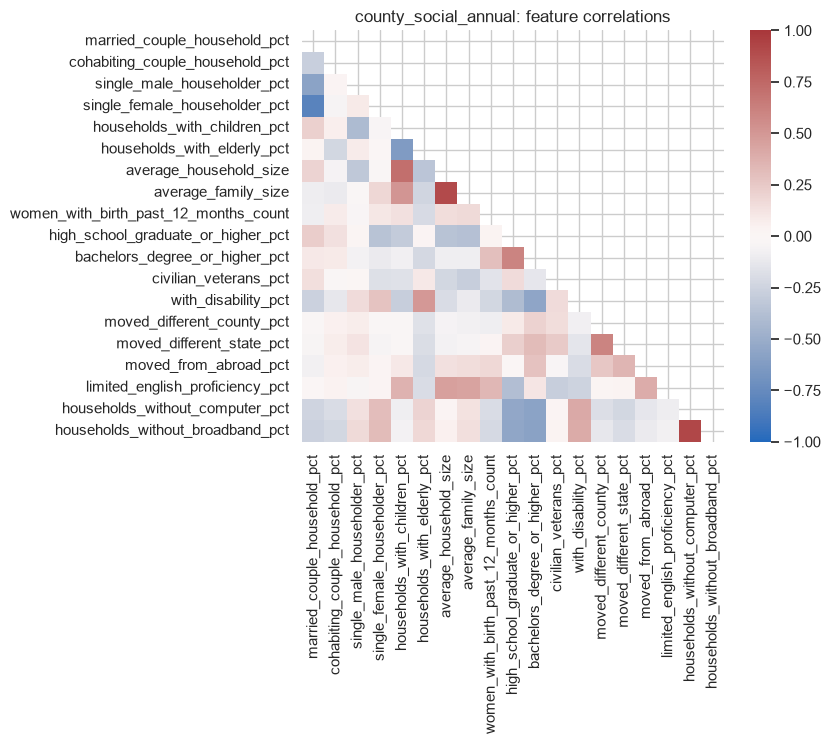

,feature_a,feature_b,correlation,abs_correlation
359,households_without_broadband_pct,households_without_computer_pct,0.921051,0.921051
139,average_family_size,average_household_size,0.901861,0.901861
57,single_female_householder_pct,married_couple_household_pct,-0.810164,0.810164
118,average_household_size,households_with_children_pct,0.712080,0.712080
99,households_with_elderly_pct,households_with_children_pct,-0.627264,0.627264
279,moved_different_state_pct,moved_different_county_pct,0.606198,0.606198
199,bachelors_degree_or_higher_pct,high_school_graduate_or_higher_pct,0.604298,0.604298
352,households_without_broadband_pct,bachelors_degree_or_higher_pct,-0.585389,0.585389
38,single_male_householder_pct,married_couple_household_pct,-0.577111,0.577111
333,households_without_computer_pct,bachelors_degree_or_higher_pct,-0.574544,0.574544


In [5]:
for table in FEATURE_TABLES:
    frame = con.execute(f"SELECT * FROM feature.{table}").df()
    numeric = frame.select_dtypes(include=np.number).drop(columns=["year"], errors="ignore")
    if numeric.shape[1] < 2:
        continue
    corr = numeric.corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    fig, ax = plt.subplots(figsize=(max(8, 0.45 * len(corr)), max(6, 0.4 * len(corr))))
    sns.heatmap(corr, mask=mask, cmap="vlag", center=0, vmin=-1, vmax=1, ax=ax)
    ax.set_title(f"{table}: feature correlations")
    plt.tight_layout()
    plt.show()

    pairs = corr.where(~mask).stack().rename("correlation").reset_index()
    pairs.columns = ["feature_a", "feature_b", "correlation"]
    display(pairs.assign(abs_correlation=pairs["correlation"].abs()).sort_values("abs_correlation", ascending=False).head(20))

## Temporal coverage and trends

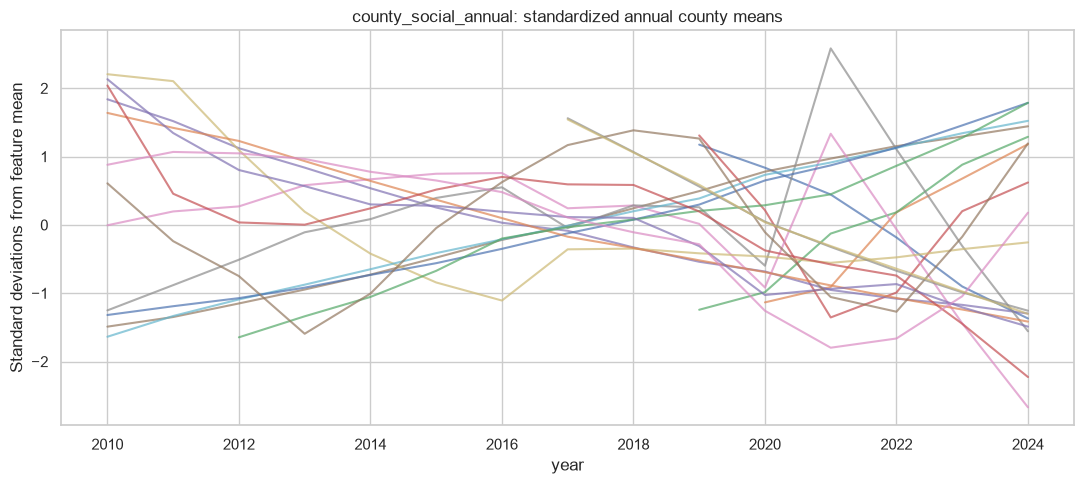

,year,married_couple_household_pct,cohabiting_couple_household_pct,single_male_householder_pct,single_female_householder_pct,households_with_children_pct,households_with_elderly_pct,average_household_size,average_family_size,women_with_birth_past_12_months_count,high_school_graduate_or_higher_pct,bachelors_degree_or_higher_pct,civilian_veterans_pct,with_disability_pct,moved_different_county_pct,moved_different_state_pct,moved_from_abroad_pct,limited_english_proficiency_pct,households_without_computer_pct,households_without_broadband_pct
0,2010,NaN,NaN,NaN,NaN,32.115113,27.733089,2.512984,3.044337,1370.916322,83.107254,19.033758,11.528126,NaN,6.644671,2.356475,0.332326,3.458320,NaN,NaN
1,2011,NaN,NaN,NaN,NaN,31.733726,28.128985,2.517563,3.053318,1366.965594,83.683233,19.267801,11.238435,NaN,6.406682,2.290964,0.321063,3.471715,NaN,NaN
2,2012,NaN,NaN,NaN,NaN,31.261120,28.686987,2.519236,3.062361,1327.716806,84.143907,19.483519,10.984537,15.342794,6.343557,2.245880,0.314254,3.470220,NaN,NaN
3,2013,NaN,NaN,NaN,NaN,30.922431,29.259179,2.526246,3.072122,1292.643361,84.553548,19.762329,10.594178,15.445975,6.338594,2.226312,0.303023,3.464429,NaN,NaN
4,2014,NaN,NaN,NaN,NaN,30.562222,29.872088,2.528208,3.076795,1268.773179,84.982081,20.101782,10.210312,15.541152,6.374539,2.204010,0.310853,3.451018,NaN,NaN
5,2015,NaN,NaN,NaN,NaN,30.226225,30.572120,2.530048,3.084335,1252.373757,85.429726,20.414354,9.846149,15.669319,6.415722,2.202292,0.323616,3.441948,NaN,NaN
6,2016,NaN,NaN,NaN,NaN,29.960885,31.300637,2.530280,3.088119,1242.089509,85.811585,20.796817,9.489052,15.828103,6.443666,2.195099,0.332559,3.429822,NaN,NaN
7,2017,NaN,NaN,NaN,NaN,29.819987,31.872470,2.518609,3.073654,1271.235837,86.191248,21.210185,9.129344,15.883291,6.427276,2.188606,0.339784,3.403342,18.556111,30.079599
8,2018,NaN,NaN,NaN,NaN,29.529472,32.600477,2.519539,3.081690,1271.646085,86.592648,21.573170,8.910694,15.921674,6.425947,2.187584,0.342662,3.387969,16.584309,27.309134
9,2019,50.554870,NaN,17.973488,25.632081,29.279281,33.306365,2.513450,3.081025,1268.966264,86.947899,21.975207,8.671006,15.963622,6.367664,2.153246,0.341057,3.375525,14.566709,24.601400


In [6]:
for table in FEATURE_TABLES:
    schema = con.execute(f"DESCRIBE feature.{table}").df()
    numeric = schema.loc[schema["column_type"].str.contains("DOUBLE|FLOAT|DECIMAL|INTEGER|BIGINT", case=False), "column_name"].tolist()
    numeric = [column for column in numeric if column != "year"]
    if not numeric:
        continue
    expressions = ", ".join(f'avg("{column}") AS "{column}"' for column in numeric)
    annual = con.execute(f"SELECT year, {expressions} FROM feature.{table} GROUP BY year ORDER BY year").df()
    normalized = annual.set_index("year").apply(lambda s: (s - s.mean()) / s.std() if s.std() else 0)
    fig, ax = plt.subplots(figsize=(11, 5))
    normalized.plot(ax=ax, legend=False, alpha=0.7)
    ax.set_title(f"{table}: standardized annual county means")
    ax.set_ylabel("Standard deviations from feature mean")
    plt.tight_layout()
    plt.show()
    display(annual)

con.close()

## Interpretation notes

- ACS values are five-year estimates associated with their release year. Adjacent years therefore contain overlapping survey periods. Five-year estimates are favored over one-year estimates in this project because the former offers complete annual data over the time period defined in the project's scope, while the latter does not.
- Monetary ACS features and the housing target are expressed in 2024 dollars.
- A null before a feature's `first_year` can indicate that ACS had not yet published a reconciled definition.
- `target_median_owner_occupied_home_value_2024_usd` is the official DP04 median, because DP04 does not publish a county average housing-unit value.
- The canonical registry and transactional build are the authority for cross-year compatibility.